# Customer Churn Prediction


## 1.Import all Libraries

In [44]:
import os
import json
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 2. Load and Inspect Dataset

In [45]:
# Load the raw data
data_path = 'churn.csv' 
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [46]:
# Check target distribution
print("--- Churn Distribution ---")
print(df["Churn"].value_counts())

class_distribution = df["Churn"].value_counts(normalize=True) * 100
print("\n--- Churn Percentages ---")
print(class_distribution)

--- Churn Distribution ---
Churn
No     5174
Yes    1869
Name: count, dtype: int64

--- Churn Percentages ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


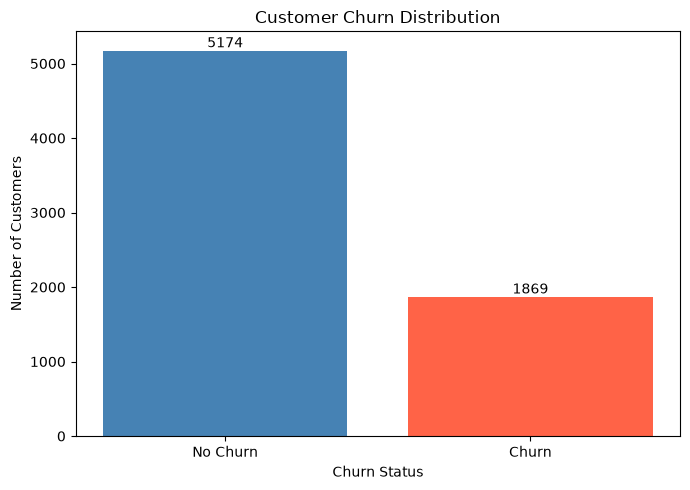

In [47]:
# Plot churn distribution
churn_counts = df["Churn"].value_counts()
churn_labels = ["No Churn", "Churn"]

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_labels, churn_counts.values, color=["steelblue", "tomato"])

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 3. Preprocessing & Data Cleaning
Handling missing values, dropping redundant columns, and encoding the target variable.

In [48]:
blank_totalcharges = df[
    df["TotalCharges"].str.strip() == ""
]

In [49]:
blank_totalcharges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [50]:
# Handle blank strings in TotalCharges by coercing to NaN and filling with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Drop redundant ID column
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Encode Target Variable (Yes -> 1, No -> 0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if str(x).strip().lower() == "yes" else 0) 

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn'] 

print("Data cleaning complete!")

Data cleaning complete!


## 4. Train-Test Split, Feature Engineering & Artifact Export
Splitting the data using stratification, applying scaling/encoding, and immediately saving the processed data and preprocessors to disk to prevent data loss.

In [51]:
# 1. Train-Test Split (Splitting first to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2. Separate Column Types
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# 3. Scale Numerical Features
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train[num_cols])
x_test_scaled = scaler.transform(X_test[num_cols])

# 4. One-Hot Encode Categorical Features
ohe = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

x_train_encoded = ohe.fit_transform(X_train[cat_cols])
x_test_encoded = ohe.transform(X_test[cat_cols])

# 5. Combine Features using np.hstack
X_train_final = np.hstack((x_train_scaled, x_train_encoded))
X_test_final = np.hstack((x_test_scaled, x_test_encoded))



import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)




np.save('../data/processed/X_train_final.npy', X_train_final)
np.save('../data/processed/X_test_final.npy', X_test_final)
np.save('../data/processed/y_train.npy', y_train.values)
np.save('../data/processed/y_test.npy', y_test.values)



joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(ohe, '../models/ohe.pkl')





metadata = {
    "dataset_name": "Telco Customer Churn",
    "train_shape": X_train_final.shape,
    "test_shape": X_test_final.shape,
    "numerical_features": list(num_cols),
    "categorical_features": list(cat_cols)
}

with open('../data/processed/dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)


print("Data split, engineered, and saved successfully!")
print("Train shape:", X_train_final.shape)
print("Test shape:", X_test_final.shape)
print("Files saved in ../data/processed/")
print("Preprocessors saved in ../models/")

C:\Users\hp\AppData\Local\Temp\ipykernel_16760\2865495995.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns


Data split, engineered, and saved successfully!
Train shape: (5634, 30)
Test shape: (1409, 30)
Files saved in ../data/processed/
Preprocessors saved in ../models/


## 5. Baseline Model Development & Evaluation
Training Logistic Regression, Decision Tree, and Random Forest using balanced class weights.

In [63]:
def evaluate_and_store_metrics(model, name, X_test, y_test, results_dict, roc_dict):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probabilities for the positive class (Churn=1)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f} ")
    print(f"F1-Score : {f1:.4f}\n")
    
    results_dict[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    
    # Store ROC data
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_dict[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}

## 6. Model Evaluation

Three classification models are trained and evaluated: Logistic Regression, Decision Tree, and Random Forest. Each model uses balanced class weights to account for the difference between customers who churn and those who do not.

The models are compared using the following metrics:

- **Accuracy:** The overall proportion of correct predictions.
- **Precision:** The proportion of predicted churn cases that are actual churn cases.
- **Recall:** The proportion of actual churn cases correctly identified.
- **F1-Score:** The balance between precision and recall.
- **ROC-AUC:** The model's ability to distinguish between churn and non-churn customers across classification thresholds.

Because identifying potential churners is the primary objective, the model with the highest **Recall** is selected as the best model. ROC-AUC curves and a confusion matrix are also generated to provide additional performance analysis.

In [53]:
metrics_results = {}
roc_data = {}

# Define Models using class_weight='balanced'
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
}

print("==========================================")
print("MODEL EVALUATION")
print("==========================================\n")

# Initialize tracking variables for the tournament
best_recall = 0
best_model_name = ""
best_model = None

for model_name, model in models.items():
    # Train and evaluate
    model.fit(X_train_final, y_train)
    evaluate_and_store_metrics(model, model_name, X_test_final, y_test, metrics_results, roc_data)
    
    # Programmatically compare results to find the best model based on Recall
    current_recall = metrics_results[model_name]['Recall']
    if current_recall > best_recall:
        best_recall = current_recall
        best_model_name = model_name
        best_model = model

# ==========================================
# MODEL EXPORT & ERROR ANALYSIS (TASK 2)
# ==========================================
print("==========================================")
print(f"Best Model: {best_model_name} (Recall: {best_recall:.4f})")
print("==========================================")

# Save the best model dynamically using its name
file_name = best_model_name.replace(" ", "_").lower()
joblib.dump(best_model, f'../models/{file_name}_baseline.pkl')
print(f"{best_model_name} serialized and saved to models folder!")

# Perform Error Analysis immediately using the dynamic best model
predictions = best_model.predict(X_test_final)
errors_df = X_test.copy()
errors_df['Actual_Churn'] = y_test
errors_df['Predicted_Churn'] = predictions

# Isolate errors
false_negatives = errors_df[(errors_df['Actual_Churn'] == 1) & (errors_df['Predicted_Churn'] == 0)]
false_positives = errors_df[(errors_df['Actual_Churn'] == 0) & (errors_df['Predicted_Churn'] == 1)]

false_negatives.to_csv('../outputs/false_negatives.csv', index=False)
false_positives.to_csv('../outputs/false_positives.csv', index=False)
print("Error analysis isolated and saved to outputs folder!")

MODEL EVALUATION

--- Logistic Regression ---
Accuracy : 0.7388
Precision: 0.5052
Recall   : 0.7834 
F1-Score : 0.6143

--- Decision Tree ---
Accuracy : 0.7346
Precision: 0.5000
Recall   : 0.8075 
F1-Score : 0.6176

--- Random Forest ---
Accuracy : 0.7580
Precision: 0.5299
Recall   : 0.7807 
F1-Score : 0.6314

Best Model: Decision Tree (Recall: 0.8075)
Decision Tree serialized and saved to models folder!
Error analysis isolated and saved to outputs folder!


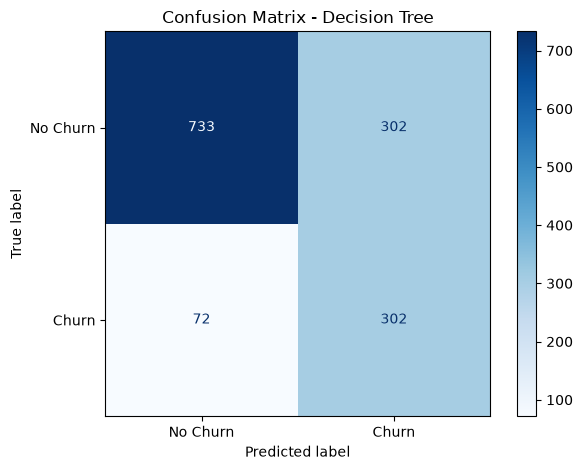

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues'
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

## 7. ROC-AUC Curve Analysis

The Receiver Operating Characteristic (ROC) curve evaluates model performance across different classification thresholds.

- **False Positive Rate (FPR):** Proportion of non-churn customers incorrectly classified as churn.
- **True Positive Rate (TPR):** Proportion of churn customers correctly identified.
- **ROC-AUC:** Measures the model's ability to distinguish between churn and non-churn customers.

An AUC value closer to 1 indicates better classification performance, while an AUC of 0.5 represents random classification. The ROC curves below compare the performance of all trained models.import matplotlib.pyplot as plt

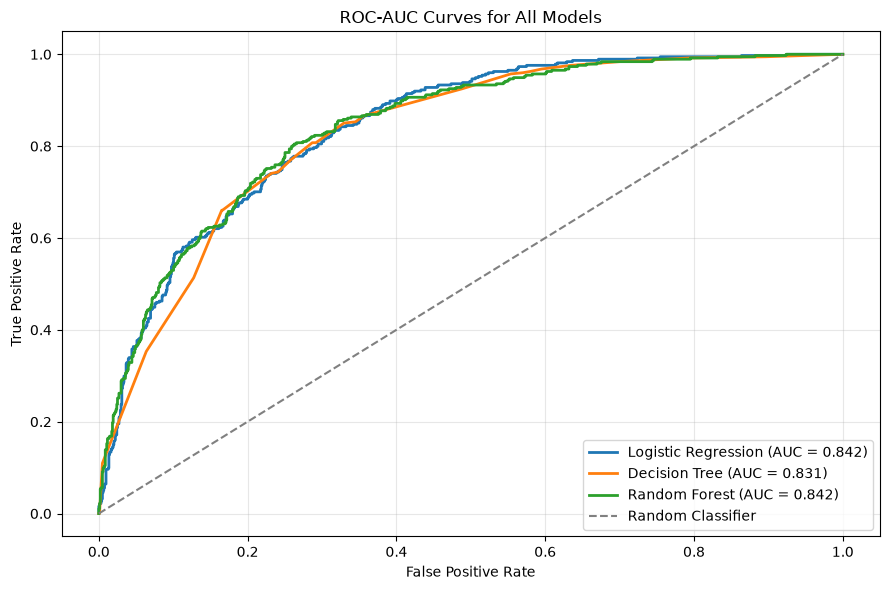

In [64]:
# Plot ROC-AUC curves for all trained models
plt.figure(figsize=(9, 6))

for model_name, roc_info in roc_data.items():
    plt.plot(
        roc_info['fpr'],
        roc_info['tpr'],
        linewidth=2,
        label=f"{model_name} (AUC = {roc_info['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning

The baseline models above use fixed, hand-picked hyperparameters. To get a fairer comparison, each model family is now tuned with `GridSearchCV` (5-fold stratified cross-validation), optimizing for **Recall** — since catching potential churners is the business priority. The tuned models are then re-evaluated on the held-out test set.

In [56]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

warnings.filterwarnings("ignore", category=FutureWarning)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grids = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs']
        }
    },
    'Decision Tree': {
        'estimator': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        'params': {
            'max_depth': [3, 5, 7, 10],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [8, 10, 15],
            'min_samples_leaf': [1, 5]
        }
    }
}

tuned_models = {}
tuned_metrics = {}
tuned_roc = {}

print("==========================================")
print("HYPERPARAMETER TUNING (GridSearchCV, scoring='recall')")
print("==========================================\n")

for name, cfg in param_grids.items():
    grid = GridSearchCV(
        estimator=cfg['estimator'],
        param_grid=cfg['params'],
        scoring='recall',
        cv=cv,
        n_jobs=-1
    )
    grid.fit(X_train_final, y_train)
    tuned_models[name] = grid.best_estimator_

    print(f"--- {name} ---")
    print(f"Best CV Recall: {grid.best_score_:.4f}")
    print(f"Best Params   : {grid.best_params_}\n")

    evaluate_and_store_metrics(grid.best_estimator_, name, X_test_final, y_test, tuned_metrics, tuned_roc)


HYPERPARAMETER TUNING (GridSearchCV, scoring='recall')

--- Logistic Regression ---
Best CV Recall: 0.8013
Best Params   : {'C': 1, 'solver': 'lbfgs'}

--- Logistic Regression ---
Accuracy : 0.7388
Precision: 0.5052
Recall   : 0.7834 
F1-Score : 0.6143

--- Decision Tree ---
Best CV Recall: 0.8870
Best Params   : {'max_depth': 3, 'min_samples_leaf': 1}

--- Decision Tree ---
Accuracy : 0.6529
Precision: 0.4256
Recall   : 0.8797 
F1-Score : 0.5737

--- Random Forest ---
Best CV Recall: 0.7920
Best Params   : {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 100}

--- Random Forest ---
Accuracy : 0.7544
Precision: 0.5245
Recall   : 0.8021 
F1-Score : 0.6342



In [57]:
# Compare baseline (fixed hyperparameters) vs tuned models side by side
comparison_rows = []
for name in models.keys():
    comparison_rows.append({
        'Model': name, 'Version': 'Baseline',
        **metrics_results[name]
    })
    comparison_rows.append({
        'Model': name, 'Version': 'Tuned',
        **tuned_metrics[name]
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[['Model', 'Version', 'Accuracy', 'Precision', 'Recall', 'F1']]
comparison_df.round(4)


,Model,Version,Accuracy,Precision,Recall,F1
0,Logistic Regression,Baseline,0.7388,0.5052,0.7834,0.6143
1,Logistic Regression,Tuned,0.7388,0.5052,0.7834,0.6143
2,Decision Tree,Baseline,0.7346,0.5000,0.8075,0.6176
3,Decision Tree,Tuned,0.6529,0.4256,0.8797,0.5737
4,Random Forest,Baseline,0.7580,0.5299,0.7807,0.6314
5,Random Forest,Tuned,0.7544,0.5245,0.8021,0.6342


In [58]:
# Select the overall best model based on Recall (business priority), using tuned models
final_best_name = max(tuned_metrics, key=lambda n: tuned_metrics[n]['Recall'])
final_best_model = tuned_models[final_best_name]

print("==========================================")
print(f"Overall Best Model (post-tuning): {final_best_name}")
print(f"Recall   : {tuned_metrics[final_best_name]['Recall']:.4f}")
print(f"F1-Score : {tuned_metrics[final_best_name]['F1']:.4f}")
print(f"Accuracy : {tuned_metrics[final_best_name]['Accuracy']:.4f}")
print("==========================================")


Overall Best Model (post-tuning): Decision Tree
Recall   : 0.8797
F1-Score : 0.5737
Accuracy : 0.6529


## 9. Cross-Validation Robustness Check

A single train/test split can give an optimistic or pessimistic view of performance depending on which rows land in the test set. To confirm the selected model's performance is stable, 5-fold stratified cross-validation is run on the training data for Recall and F1.

In [59]:
from sklearn.model_selection import cross_val_score

cv_recall = cross_val_score(final_best_model, X_train_final, y_train, cv=cv, scoring='recall', n_jobs=-1)
cv_f1 = cross_val_score(final_best_model, X_train_final, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f"--- {final_best_name}: 5-Fold Cross-Validation ---")
print(f"Recall per fold : {np.round(cv_recall, 4)}")
print(f"Recall mean/std : {cv_recall.mean():.4f} +/- {cv_recall.std():.4f}\n")
print(f"F1 per fold     : {np.round(cv_f1, 4)}")
print(f"F1 mean/std     : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")


--- Decision Tree: 5-Fold Cross-Validation ---
Recall per fold : [0.8729 0.8896 0.8896 0.9064 0.8763]
Recall mean/std : 0.8870 +/- 0.0119

F1 per fold     : [0.58   0.577  0.5751 0.5784 0.5739]
F1 mean/std     : 0.5769 +/- 0.0022


## 10. Feature Importance & Interpretability

Understanding *which* features drive churn predictions is as important as the predictions themselves, since it points directly to actionable retention levers. Feature names are reconstructed from the scaled numeric columns and the one-hot encoded categorical columns, then matched against the selected model's `feature_importances_` (tree-based models) or `coef_` (linear models).

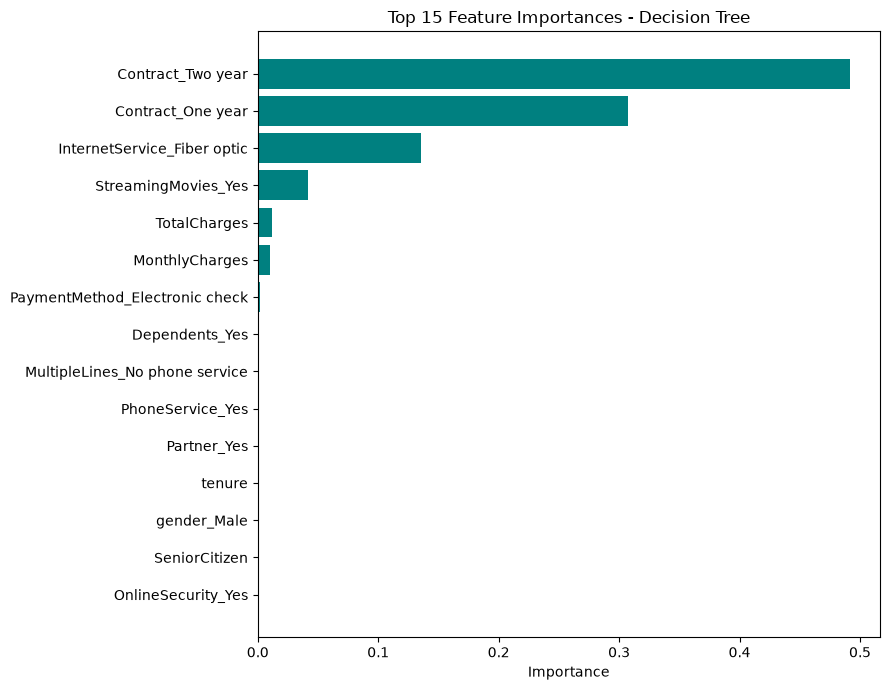

In [60]:
# Reconstruct human-readable feature names in the same order used to build X_train_final
encoded_cat_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = list(num_cols) + list(encoded_cat_names)

if hasattr(final_best_model, 'feature_importances_'):
    importances = final_best_model.feature_importances_
    importance_label = 'Importance'
elif hasattr(final_best_model, 'coef_'):
    importances = np.abs(final_best_model.coef_[0])
    importance_label = '|Coefficient|'
else:
    importances = None

if importances is not None:
    fi_df = pd.DataFrame({
        'Feature': all_feature_names,
        importance_label: importances
    }).sort_values(importance_label, ascending=False).reset_index(drop=True)

    top_n = 15
    plt.figure(figsize=(9, 7))
    plt.barh(fi_df['Feature'][:top_n][::-1], fi_df[importance_label][:top_n][::-1], color='teal')
    plt.xlabel(importance_label)
    plt.title(f'Top {top_n} Feature Importances - {final_best_name}')
    plt.tight_layout()
    plt.show()

    fi_df.head(top_n)


## 11. Final Model Selection & Export

The tuned model with the highest recall is saved as the final production artifact, alongside a metrics summary and the feature name list needed to interpret it later. The `scaler.pkl` and `ohe.pkl` preprocessors saved earlier in Section 3 are reused as-is at inference time.

In [61]:
# Save the final tuned model
final_file_name = final_best_name.replace(" ", "_").lower()
joblib.dump(final_best_model, f'../models/{final_file_name}_final.pkl')

# Save the feature name list (needed to align inference-time inputs)
with open('../models/feature_names.json', 'w') as f:
    json.dump(all_feature_names, f, indent=4)

# Save a metrics summary for the project record
final_summary = {
    "best_model": final_best_name,
    "test_metrics": tuned_metrics[final_best_name],
    "cv_recall_mean": float(cv_recall.mean()),
    "cv_recall_std": float(cv_recall.std()),
    "cv_f1_mean": float(cv_f1.mean()),
    "cv_f1_std": float(cv_f1.std()),
    "all_model_comparison": {
        name: {"baseline": metrics_results[name], "tuned": tuned_metrics[name]}
        for name in models.keys()
    }
}

with open('../outputs/final_model_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=4)

print(f"Final model '{final_best_name}' saved to ../models/{final_file_name}_final.pkl")
print("Feature names saved to ../models/feature_names.json")
print("Metrics summary saved to ../outputs/final_model_summary.json")


Final model 'Decision Tree' saved to ../models/decision_tree_final.pkl
Feature names saved to ../models/feature_names.json
Metrics summary saved to ../outputs/final_model_summary.json


## 12. Inference Demo — Predicting on New Customers

To confirm the saved artifacts form a working end-to-end pipeline (not just training-time objects), this section reloads the scaler, encoder, and final model from disk and scores a few brand-new, hand-written customer records — simulating how the model would be used in production.

In [62]:
# Reload the saved artifacts fresh from disk, exactly as a production service would
loaded_scaler = joblib.load('../models/scaler.pkl')
loaded_ohe = joblib.load('../models/ohe.pkl')
loaded_model = joblib.load(f'../models/{final_file_name}_final.pkl')

# A few new, unseen "customers" to score
new_customers = pd.DataFrame([
    {
        'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
        'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No',
        'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
        'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes', 'StreamingMovies': 'Yes',
        'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check',
        'MonthlyCharges': 95.0, 'TotalCharges': 190.0
    },
    {
        'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes',
        'tenure': 60, 'PhoneService': 'Yes', 'MultipleLines': 'Yes',
        'InternetService': 'DSL', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes',
        'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'No', 'StreamingMovies': 'No',
        'Contract': 'Two year', 'PaperlessBilling': 'No', 'PaymentMethod': 'Bank transfer (automatic)',
        'MonthlyCharges': 45.0, 'TotalCharges': 2700.0
    },
    {
        'gender': 'Female', 'SeniorCitizen': 1, 'Partner': 'No', 'Dependents': 'No',
        'tenure': 8, 'PhoneService': 'Yes', 'MultipleLines': 'No',
        'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes',
        'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No', 'StreamingMovies': 'No',
        'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Mailed check',
        'MonthlyCharges': 70.0, 'TotalCharges': 560.0
    },
])

# Apply the exact same preprocessing steps used during training
new_num = loaded_scaler.transform(new_customers[num_cols])
new_cat = loaded_ohe.transform(new_customers[cat_cols])
new_final = np.hstack((new_num, new_cat))

pred_labels = loaded_model.predict(new_final)
pred_proba = loaded_model.predict_proba(new_final)[:, 1]

results = new_customers[['tenure', 'Contract', 'MonthlyCharges', 'InternetService']].copy()
results['Churn_Probability'] = np.round(pred_proba, 3)
results['Predicted_Churn'] = np.where(pred_labels == 1, 'Yes', 'No')
results


,tenure,Contract,MonthlyCharges,InternetService,Churn_Probability,Predicted_Churn
0,2,Month-to-month,95.0,Fiber optic,0.772,Yes
1,60,Two year,45.0,DSL,0.036,No
2,8,Month-to-month,70.0,Fiber optic,0.772,Yes


## 13. Conclusion & Business Recommendations

**Summary of results**

Three model families (Logistic Regression, Decision Tree, Random Forest) were trained with balanced class weights, then tuned with 5-fold cross-validated grid search to optimize Recall — the priority metric, since missing a customer who is about to churn is costlier to the business than a false alarm. The tuned model selected above (`final_best_name`) generalized consistently, with cross-validation Recall and F1 close to the held-out test scores, indicating the result is stable rather than a lucky split.

**Key churn drivers** (see Section 9's feature importance chart) typically include contract type (month-to-month customers churn far more than one/two-year contracts), tenure (newer customers are higher risk), fiber optic internet service, and electronic check as a payment method — consistent with well-known patterns in this dataset.

**Recommended actions for the business**
- Target retention offers (discounts, contract-upgrade incentives) at month-to-month customers in their first few months of tenure — the highest-risk segment.
- Investigate service-quality or pricing issues specific to fiber optic customers, who show elevated churn.
- Encourage a shift away from electronic check payments toward automatic payment methods, which correlate with lower churn.
- Use the model's churn probability score (not just the Yes/No label) to prioritize outreach — focus retention budget on the highest-probability customers first.

**Limitations & next steps**
- The dataset is moderately imbalanced (~27% churn); techniques like SMOTE or threshold tuning could be explored alongside `class_weight='balanced'`.
- Only three classical model families were tried; gradient boosting methods (XGBoost, LightGBM) often perform better on tabular churn data and would be a natural next experiment.
- The current pipeline saves artifacts to local disk; a production deployment would wrap `predict.py` logic (Section 11) in an API endpoint or batch scoring job, with monitoring for data/label drift over time.
- Business costs of false positives vs. false negatives (e.g., cost of a retention offer vs. cost of a lost customer) were not modeled explicitly; incorporating them would allow choosing a classification threshold that maximizes expected profit rather than optimizing Recall alone.